# Анализ данных — занятие 2
### Закон больших чисел, ЦПТ, квантили (CDF/PPF) и проверка гипотез

**Логика занятия:** почему среднее становится устойчивее с ростом выборки → центральная предельная теорема → как через CDF/PPF находить квантили → доверительные интервалы → проверка гипотез и матрица ошибок.

## 1. Закон больших чисел

Чем больше мы усредняем независимых величин, тем меньше разброс среднего: выборочное среднее приближается к истинному среднему генеральной совокупности.

## 2. Центральная предельная теорема (ЦПТ)

Среднее `n` независимых одинаково распределённых величин распределено приблизительно нормально:

$$\bar{x} \sim N\!\left(M_0,\; \frac{\sigma_0}{\sqrt{n}}\right)$$

То есть центр — истинное среднее `M₀`, а разброс уменьшается как `σ₀/√n`.

Проверим на равномерном распределении: возьмём 1000 выборок по 10 значений и сравним распределение одного значения со распределением среднего.

In [1]:
%matplotlib inline
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 4)

среднее: 0.4942 | СКО: 0.2876


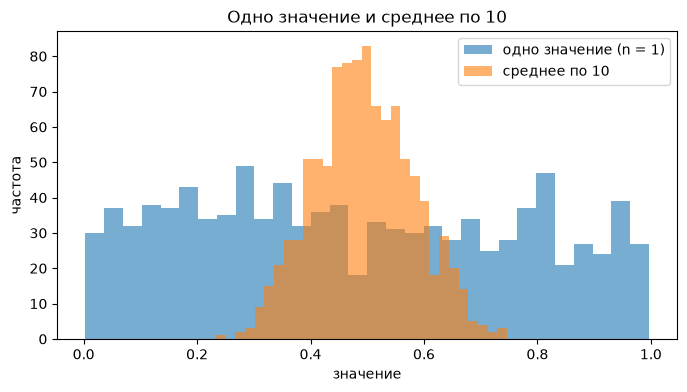

In [2]:
uniform = ss.uniform()
x = uniform.rvs(size=(1000, 10))   # 1000 выборок по 10 значений

mu0, sigma0 = x.mean(), x.std()
print("среднее:", round(mu0, 4), "| СКО:", round(sigma0, 4))

plt.hist(x[:, 0], bins=30, alpha=0.6, label="одно значение (n = 1)")
plt.hist(x.mean(axis=-1), bins=30, alpha=0.6, label="среднее по 10")
plt.title("Одно значение и среднее по 10")
plt.xlabel("значение")
plt.ylabel("частота")
plt.legend()
plt.show()

Наложим на распределение средних теоретическую нормальную кривую `N(μ, σ/√n)` — она хорошо совпадает:

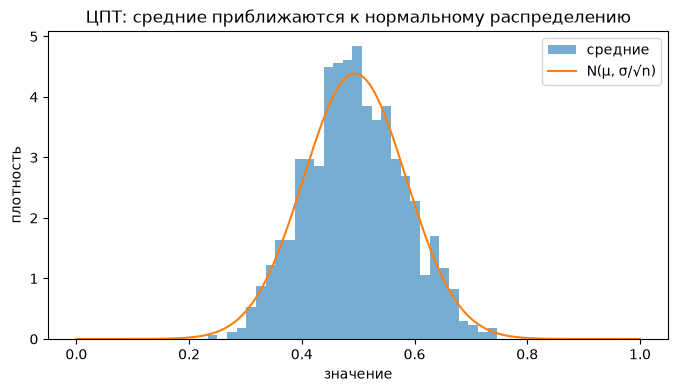

In [3]:
n = 10
dn = ss.norm(loc=mu0, scale=sigma0 / np.sqrt(n))
xs = np.linspace(0, 1, 1000)

plt.hist(x.mean(axis=-1), bins=30, density=True, alpha=0.6, label="средние")
plt.plot(xs, dn.pdf(xs), label="N(μ, σ/√n)")
plt.title("ЦПТ: средние приближаются к нормальному распределению")
plt.xlabel("значение")
plt.ylabel("плотность")
plt.legend()
plt.show()

## 3. CDF и PPF

- **CDF** (функция распределения) отвечает на вопрос «какова вероятность, что значение меньше x».
- **PPF** — обратная к CDF функция: по вероятности возвращает значение (квантиль). Через неё находят медиану и границы интервалов.

Медиана — это `PPF(0.5)`, квартили — `PPF(0.25)` и `PPF(0.75)`.

In [1]:
dist = ss.norm(loc=3.2, scale=1)

print("P(x < 6.2):", round(dist.cdf(3.2 + 3), 6))
print("P(x < 0.2):", round(dist.cdf(3.2 - 3), 6))
print("PPF(0.025):", round(dist.ppf(0.025), 4))
print("PPF(0.975):", round(dist.ppf(0.975), 4))
print("PPF(0.25): ", round(dist.ppf(0.25), 4))
print("PPF(0.75): ", round(dist.ppf(0.75), 4))
print("IQR:", round(dist.ppf(0.75) - dist.ppf(0.25), 4))

P(x < 6.2): 0.99865
P(x < 0.2): 0.00135
PPF(0.025): 1.24
PPF(0.975): 5.16
PPF(0.25):  2.5255
PPF(0.75):  3.8745
IQR: 1.349


## 4. Доверительный интервал

**Доверительный интервал** — интервал, в который попадает нужная доля значений. Бывает левосторонний, правосторонний и двусторонний; в статистике чаще пользуются двусторонним.

Если уровень значимости не задан, по умолчанию берут **5%** — это доверительный интервал 95%.

In [5]:
alpha = 0.05
lo = dist.ppf(alpha / 2)
hi = dist.ppf(1 - alpha / 2)

print(f"уровень значимости: {alpha}")
print(f"95%-й доверительный интервал: [{lo:.4f}, {hi:.4f}]")

уровень значимости: 0.05
95%-й доверительный интервал: [1.2400, 5.1600]


## 5. Проверка гипотез

- **H₀** — нулевая (основная) гипотеза; по смыслу это презумпция невиновности.
- **H₁** — альтернативная гипотеза, обратная H₀.

Матрица ошибок:

|  | H₀ верна (джедаи) | H₁ верна (ситхи) |
| --- | --- | --- |
| приняли H₀ | TP | FT |
| приняли H₁ | FN | TN |

где TP — true positive, FP — false positive, TN — true negative, FN — false negative.

Пример: из 1000 человек реально невиновны 988, виновны 12.

- 980 невиновных признали невиновными (TN)
- 8 невиновных назвали преступниками (FP)
- 10 виновных признали (TP)
- 2 виновных отпустили (FN)

Верно 990 из 1000 — точность 99%.

In [6]:
tn, fp, fn, tp = 980, 8, 2, 10
total = tp + tn + fp + fn
accuracy = (tp + tn) / total

print("всего:", total)
print("верно:", tp + tn, "| ошиблись:", fp + fn)
print("точность:", round(accuracy, 4))

всего: 1000
верно: 990 | ошиблись: 10
точность: 0.99


---

**Итог занятия 2.** Разобрали закон больших чисел и ЦПТ (средние сходятся к нормальному распределению `N(μ, σ/√n)`), научились работать с CDF/PPF для поиска квантилей, построили доверительный интервал и разобрали проверку гипотез с матрицей ошибок TP/FP/TN/FN.